# UC2 — DDoS Detection: CICIDS2017 Data Preparation

**Goal:** Load, clean, explore, and prepare the CICIDS2017 network flow dataset
for XGBoost-based binary DDoS classification (Benign vs DDoS).

### Data Source

CICIDS2017 — Canadian Institute for Cybersecurity (July 3–7, 2017).
Network flows extracted by CICFlowMeter with ~80 features per flow + label column.

| File | Day | Content | Role |
|------|-----|---------|------|
| `Monday-WorkingHours.pcap_ISCX.csv` | Mon Jul 3 | All BENIGN | Training (benign baseline) |
| `Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv` | Fri Jul 7 PM | BENIGN + DDoS | Training (attack) + Testing |
| `Friday-WorkingHours-Morning.pcap_ISCX.csv` | Fri Jul 7 AM | BENIGN only | Additional benign (optional) |

### Pipeline

1. Load CSVs, strip column-name whitespace (CICFlowMeter quirk)
2. Initial exploration: shape, dtypes, label distribution
3. Clean: handle NaN, infinity, duplicate rows
4. Drop constant/near-constant columns
5. Correlation analysis → reduce to 15–25 features
6. Temporal split within Friday (train/test boundary)
7. Export clean CSVs for downstream XGBoost training notebook

### Design Constraints

- **Ground truth integrity:** Labels are provided by CIC — no circular labeling risk.
- **Feature parity:** The feature set selected here defines what both UC2 (XGBoost)
  and UC4 (Isolation Forest, unsupervised) will use on flow data.
- **No data leakage:** Temporal split, never random split.

In [1]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.max_colwidth', 40)

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['figure.dpi'] = 100

print('Libraries loaded.')

Libraries loaded.


## 1. Configuration

In [2]:
# ── Point this at your MachineLearningCSV folder ──
DATA_DIR = './data/CIC-IDS-2017/'

# Files to load for UC2 (DDoS detection)
FILES = {
    'monday':       'Monday-WorkingHours.pcap_ISCX.csv',
    'friday_ddos':  'Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv',
    'friday_morn':  'Friday-WorkingHours-Morning.pcap_ISCX.csv',
}

# Output directory for cleaned CSVs
OUTPUT_DIR = './data/'
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Correlation threshold for dropping redundant features
CORR_THRESHOLD = 0.95

print(f'Data directory: {DATA_DIR}')
print(f'Output directory: {OUTPUT_DIR}')

Data directory: ./data/CIC-IDS-2017/
Output directory: ./data/


## 2. Load Raw Data

In [3]:
dfs = {}
for key, fname in FILES.items():
    path = os.path.join(DATA_DIR, fname)
    if not os.path.exists(path):
        print(f'SKIP (not found): {path}')
        continue
    df = pd.read_csv(path, low_memory=False)
    # CICFlowMeter adds leading spaces to column names
    df.columns = df.columns.str.strip()
    dfs[key] = df
    print(f'{key:15s}    {df.shape[0]:>10,} rows × {df.shape[1]} cols  |  {fname}')

print(f'\nLoaded {len(dfs)} file(s).')

monday                529,918 rows × 85 cols  |  Monday-WorkingHours.pcap_ISCX.csv
friday_ddos           225,745 rows × 85 cols  |  Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv
friday_morn           191,033 rows × 85 cols  |  Friday-WorkingHours-Morning.pcap_ISCX.csv

Loaded 3 file(s).


## 3. Schema Consistency Check

Verify all files share the same column set before concatenation.

In [4]:
# Check column consistency across loaded files
col_sets = {k: set(df.columns) for k, df in dfs.items()}
ref_key = list(col_sets.keys())[0]
ref_cols = col_sets[ref_key]

for k, cols in col_sets.items():
    if cols == ref_cols:
        print(f'{k:15s}  columns match reference ({ref_key})')
    else:
        extra = cols - ref_cols
        missing = ref_cols - cols
        print(f'{k:15s}  MISMATCH')
        if extra:   print(f'     extra:   {extra}')
        if missing: print(f'     missing: {missing}')

print(f'\nReference columns ({len(ref_cols)}):')
for i, c in enumerate(sorted(ref_cols)):
    print(f'  {i+1:3d}. {c}')

monday           columns match reference (monday)
friday_ddos      columns match reference (monday)
friday_morn      columns match reference (monday)

Reference columns (85):
    1. ACK Flag Count
    2. Active Max
    3. Active Mean
    4. Active Min
    5. Active Std
    6. Average Packet Size
    7. Avg Bwd Segment Size
    8. Avg Fwd Segment Size
    9. Bwd Avg Bulk Rate
   10. Bwd Avg Bytes/Bulk
   11. Bwd Avg Packets/Bulk
   12. Bwd Header Length
   13. Bwd IAT Max
   14. Bwd IAT Mean
   15. Bwd IAT Min
   16. Bwd IAT Std
   17. Bwd IAT Total
   18. Bwd PSH Flags
   19. Bwd Packet Length Max
   20. Bwd Packet Length Mean
   21. Bwd Packet Length Min
   22. Bwd Packet Length Std
   23. Bwd Packets/s
   24. Bwd URG Flags
   25. CWE Flag Count
   26. Destination IP
   27. Destination Port
   28. Down/Up Ratio
   29. ECE Flag Count
   30. FIN Flag Count
   31. Flow Bytes/s
   32. Flow Duration
   33. Flow IAT Max
   34. Flow IAT Mean
   35. Flow IAT Min
   36. Flow IAT Std
   37. Flo

## 4. Label Distribution

Check what labels exist in each file. UC2 needs only `BENIGN` and `DDoS`.

In [5]:
for key, df in dfs.items():
    print(f'\n── {key} ──')
    vc = df['Label'].value_counts()
    for label, count in vc.items():
        pct = 100.0 * count / len(df)
        print(f'  {label:30s}  {count:>10,}  ({pct:5.1f}%)')


── monday ──
  BENIGN                             529,918  (100.0%)

── friday_ddos ──
  DDoS                               128,027  ( 56.7%)
  BENIGN                              97,718  ( 43.3%)

── friday_morn ──
  BENIGN                             189,067  ( 99.0%)
  Bot                                  1,966  (  1.0%)


## 5. Combine and Tag Source

Concatenate Monday (all benign) + Friday DDoS afternoon. Tag each row with its source file for later splitting.

In [6]:
frames = []
for key in ['monday', 'friday_ddos']:
    if key not in dfs:
        print(f'WARNING: {key} not loaded — skipping')
        continue
    tmp = dfs[key].copy()
    tmp['_source'] = key
    frames.append(tmp)

df_all = pd.concat(frames, ignore_index=True)
print(f'Combined shape: {df_all.shape[0]:,} rows x {df_all.shape[1]} cols')
print(f'\nSource breakdown:')
print(df_all['_source'].value_counts().to_string())
print(f'\nLabel breakdown (combined):')
print(df_all['Label'].value_counts().to_string())

Combined shape: 755,663 rows x 86 cols

Source breakdown:
_source
monday         529918
friday_ddos    225745

Label breakdown (combined):
Label
BENIGN    627636
DDoS      128027


## 6. Binary Label Encoding

Map all non-BENIGN labels to 1 (attack), BENIGN to 0.
For UC2, the only attack type present is `DDoS`.

In [7]:
# Preserve original label for analysis
df_all['label_orig'] = df_all['Label']
df_all['label'] = (df_all['Label'] != 'BENIGN').astype(int)

print('Binary label distribution:')
for lbl, count in df_all['label'].value_counts().sort_index().items():
    pct = 100.0 * count / len(df_all)
    tag = 'BENIGN' if lbl == 0 else 'ATTACK (DDoS)'
    print(f'  {lbl}  ({tag:15s})  {count:>10,}  ({pct:5.1f}%)')

Binary label distribution:
  0  (BENIGN         )     627,636  ( 83.1%)
  1  (ATTACK (DDoS)  )     128,027  ( 16.9%)


## 7. Data Type Overview

In [8]:
print('Column dtypes summary:')
print(df_all.dtypes.value_counts().to_string())

# Identify non-numeric columns (excluding metadata)
meta_cols = ['Label', 'label_orig', 'label', '_source']
non_numeric = [c for c in df_all.columns
               if c not in meta_cols and not pd.api.types.is_numeric_dtype(df_all[c])]

if non_numeric:
    print(f'\nNon-numeric feature columns ({len(non_numeric)}):')
    for c in non_numeric:
        print(f'  {c}: {df_all[c].dtype}  — sample: {df_all[c].iloc[0]}')
else:
    print('\nAll feature columns are numeric.')

Column dtypes summary:
float64    45
int64      36
str         7

Non-numeric feature columns (4):
  Flow ID: str  — sample: 192.168.10.5-8.254.250.126-49188-80-6
  Source IP: str  — sample: 8.254.250.126
  Destination IP: str  — sample: 192.168.10.5
  Timestamp: str  — sample: 03/07/2017 08:55:58


## 8. Parse Timestamp

The `Timestamp` column is a datetime string. Parse it for temporal splitting, then drop it from the feature set (it's metadata, not a model feature).

In [9]:
if 'Timestamp' in df_all.columns:
    # CICIDS2017 uses day-first format: '03/07/2017 08:55:58' = 3 July 2017.
    # Monday CSV pads with leading zeros (e.g. '03/07/2017'); Friday CSV
    # often does not (e.g. '7/7/2017 3:55'). Both are day-first.
    df_all['Timestamp'] = pd.to_datetime(
        df_all['Timestamp'], dayfirst=True, errors='coerce'
    )
    n_bad = df_all['Timestamp'].isna().sum()
    if n_bad > 0:
        print(f'WARNING: {n_bad} rows with unparseable timestamps')
    else:
        print('All timestamps parsed successfully.')

    print('\nTimestamp range per source:')
    for src in df_all['_source'].unique():
        mask = df_all['_source'] == src
        ts = df_all.loc[mask, 'Timestamp']
        print(f'  {src:15s}  {ts.min()}  ->  {ts.max()}')
else:
    print('No Timestamp column found — temporal splitting will use row order.')


Timestamp range per source:
  monday           2017-07-03 01:00:01  ->  2017-07-03 12:59:58
  friday_ddos      NaT  ->  NaT


## 9. Identify Feature Columns

Separate metadata/label columns from the actual CICFlowMeter features.

In [10]:
META_COLS = ['Label', 'label_orig', 'label', '_source', 'Timestamp']
# Some CSVs may have Flow ID, Source IP, Destination IP, etc.
ID_COLS = ['Flow ID', 'Source IP', 'Source Port', 'Destination IP',
           'Destination Port', 'Protocol']

# Keep Destination Port and Protocol as features (they carry signal)
# but drop the other ID columns (they leak identity, not behaviour)
DROP_ID = ['Flow ID', 'Source IP', 'Destination IP']
drop_id_present = [c for c in DROP_ID if c in df_all.columns]

if drop_id_present:
    print(f'Dropping identity columns: {drop_id_present}')
    df_all.drop(columns=drop_id_present, inplace=True)

feature_cols = [c for c in df_all.columns if c not in META_COLS]
print(f'\nFeature columns: {len(feature_cols)}')
for i, c in enumerate(feature_cols):
    print(f'  {i+1:3d}. {c:45s}  dtype={str(df_all[c].dtype):10s}')

Dropping identity columns: ['Flow ID', 'Source IP', 'Destination IP']

Feature columns: 80
    1. Source Port                                    dtype=int64     
    2. Destination Port                               dtype=int64     
    3. Protocol                                       dtype=int64     
    4. Flow Duration                                  dtype=int64     
    5. Total Fwd Packets                              dtype=int64     
    6. Total Backward Packets                         dtype=int64     
    7. Total Length of Fwd Packets                    dtype=float64   
    8. Total Length of Bwd Packets                    dtype=float64   
    9. Fwd Packet Length Max                          dtype=float64   
   10. Fwd Packet Length Min                          dtype=float64   
   11. Fwd Packet Length Mean                         dtype=float64   
   12. Fwd Packet Length Std                          dtype=float64   
   13. Bwd Packet Length Max                          dty

## 10. Handle NaN and Infinity Values

CICFlowMeter is known to produce `inf` values in rate columns (e.g. `Flow Bytes/s`, `Flow Packets/s`) when flow duration is zero.

In [11]:
# Convert object columns that should be numeric
for c in feature_cols:
    if df_all[c].dtype == object:
        df_all[c] = pd.to_numeric(df_all[c], errors='coerce')

# Replace inf with NaN, then report
df_all.replace([np.inf, -np.inf], np.nan, inplace=True)

nan_counts = df_all[feature_cols].isna().sum()
nan_cols = nan_counts[nan_counts > 0].sort_values(ascending=False)

if len(nan_cols) > 0:
    print(f'Columns with NaN/Inf values ({len(nan_cols)}):')
    for c, cnt in nan_cols.items():
        pct = 100.0 * cnt / len(df_all)
        print(f'  {c:45s}  {cnt:>8,} NaN  ({pct:5.2f}%)')
else:
    print('No NaN or Inf values found.')

# Strategy: fill NaN with 0 for rate columns (inf from zero-duration flows)
# This is standard practice for CICIDS2017 preprocessing.
n_before = df_all[feature_cols].isna().sum().sum()
df_all[feature_cols] = df_all[feature_cols].fillna(0)
n_after = df_all[feature_cols].isna().sum().sum()
print(f'\nFilled {n_before - n_after:,} NaN values with 0.')

Columns with NaN/Inf values (2):
  Flow Bytes/s                                        471 NaN  ( 0.06%)
  Flow Packets/s                                      471 NaN  ( 0.06%)

Filled 942 NaN values with 0.


## 11. Remove Duplicate Rows

In [12]:
n_before = len(df_all)
df_all.drop_duplicates(subset=feature_cols + ['label'], keep='first', inplace=True)
df_all.reset_index(drop=True, inplace=True)
n_after = len(df_all)
n_dropped = n_before - n_after
print(f'Dropped {n_dropped:,} duplicate rows ({100*n_dropped/n_before:.2f}%)')
print(f'Remaining: {n_after:,} rows')

Dropped 1,539 duplicate rows (0.20%)
Remaining: 754,124 rows


## 12. Drop Constant and Near-Constant Columns

Columns with zero variance carry no information for classification.

In [13]:
# Identify constant columns (std == 0)
stds = df_all[feature_cols].std()
const_cols = stds[stds == 0].index.tolist()

# Near-constant: >99.9% same value
near_const_cols = []
for c in feature_cols:
    if c in const_cols:
        continue
    top_pct = df_all[c].value_counts(normalize=True).iloc[0]
    if top_pct > 0.999:
        near_const_cols.append((c, top_pct))

print(f'Constant columns ({len(const_cols)}):')
for c in const_cols:
    val = df_all[c].iloc[0]
    print(f'  {c:45s}  value = {val}')

print(f'\nNear-constant columns ({len(near_const_cols)}):')
for c, pct in near_const_cols:
    print(f'  {c:45s}  {pct*100:.2f}% same value')

drop_cols = const_cols + [c for c, _ in near_const_cols]
if drop_cols:
    df_all.drop(columns=drop_cols, inplace=True)
    feature_cols = [c for c in feature_cols if c not in drop_cols]
    print(f'\nDropped {len(drop_cols)} columns. Remaining features: {len(feature_cols)}')
else:
    print('\nNo columns to drop.')

Constant columns (10):
  Bwd PSH Flags                                  value = 0
  Fwd URG Flags                                  value = 0
  Bwd URG Flags                                  value = 0
  CWE Flag Count                                 value = 0
  Fwd Avg Bytes/Bulk                             value = 0
  Fwd Avg Packets/Bulk                           value = 0
  Fwd Avg Bulk Rate                              value = 0
  Bwd Avg Bytes/Bulk                             value = 0
  Bwd Avg Packets/Bulk                           value = 0
  Bwd Avg Bulk Rate                              value = 0

Near-constant columns (2):
  RST Flag Count                                 99.99% same value
  ECE Flag Count                                 99.99% same value

Dropped 12 columns. Remaining features: 68


## 13. Feature Distributions: Benign vs DDoS

Visualize a sample of features to understand separation between classes.

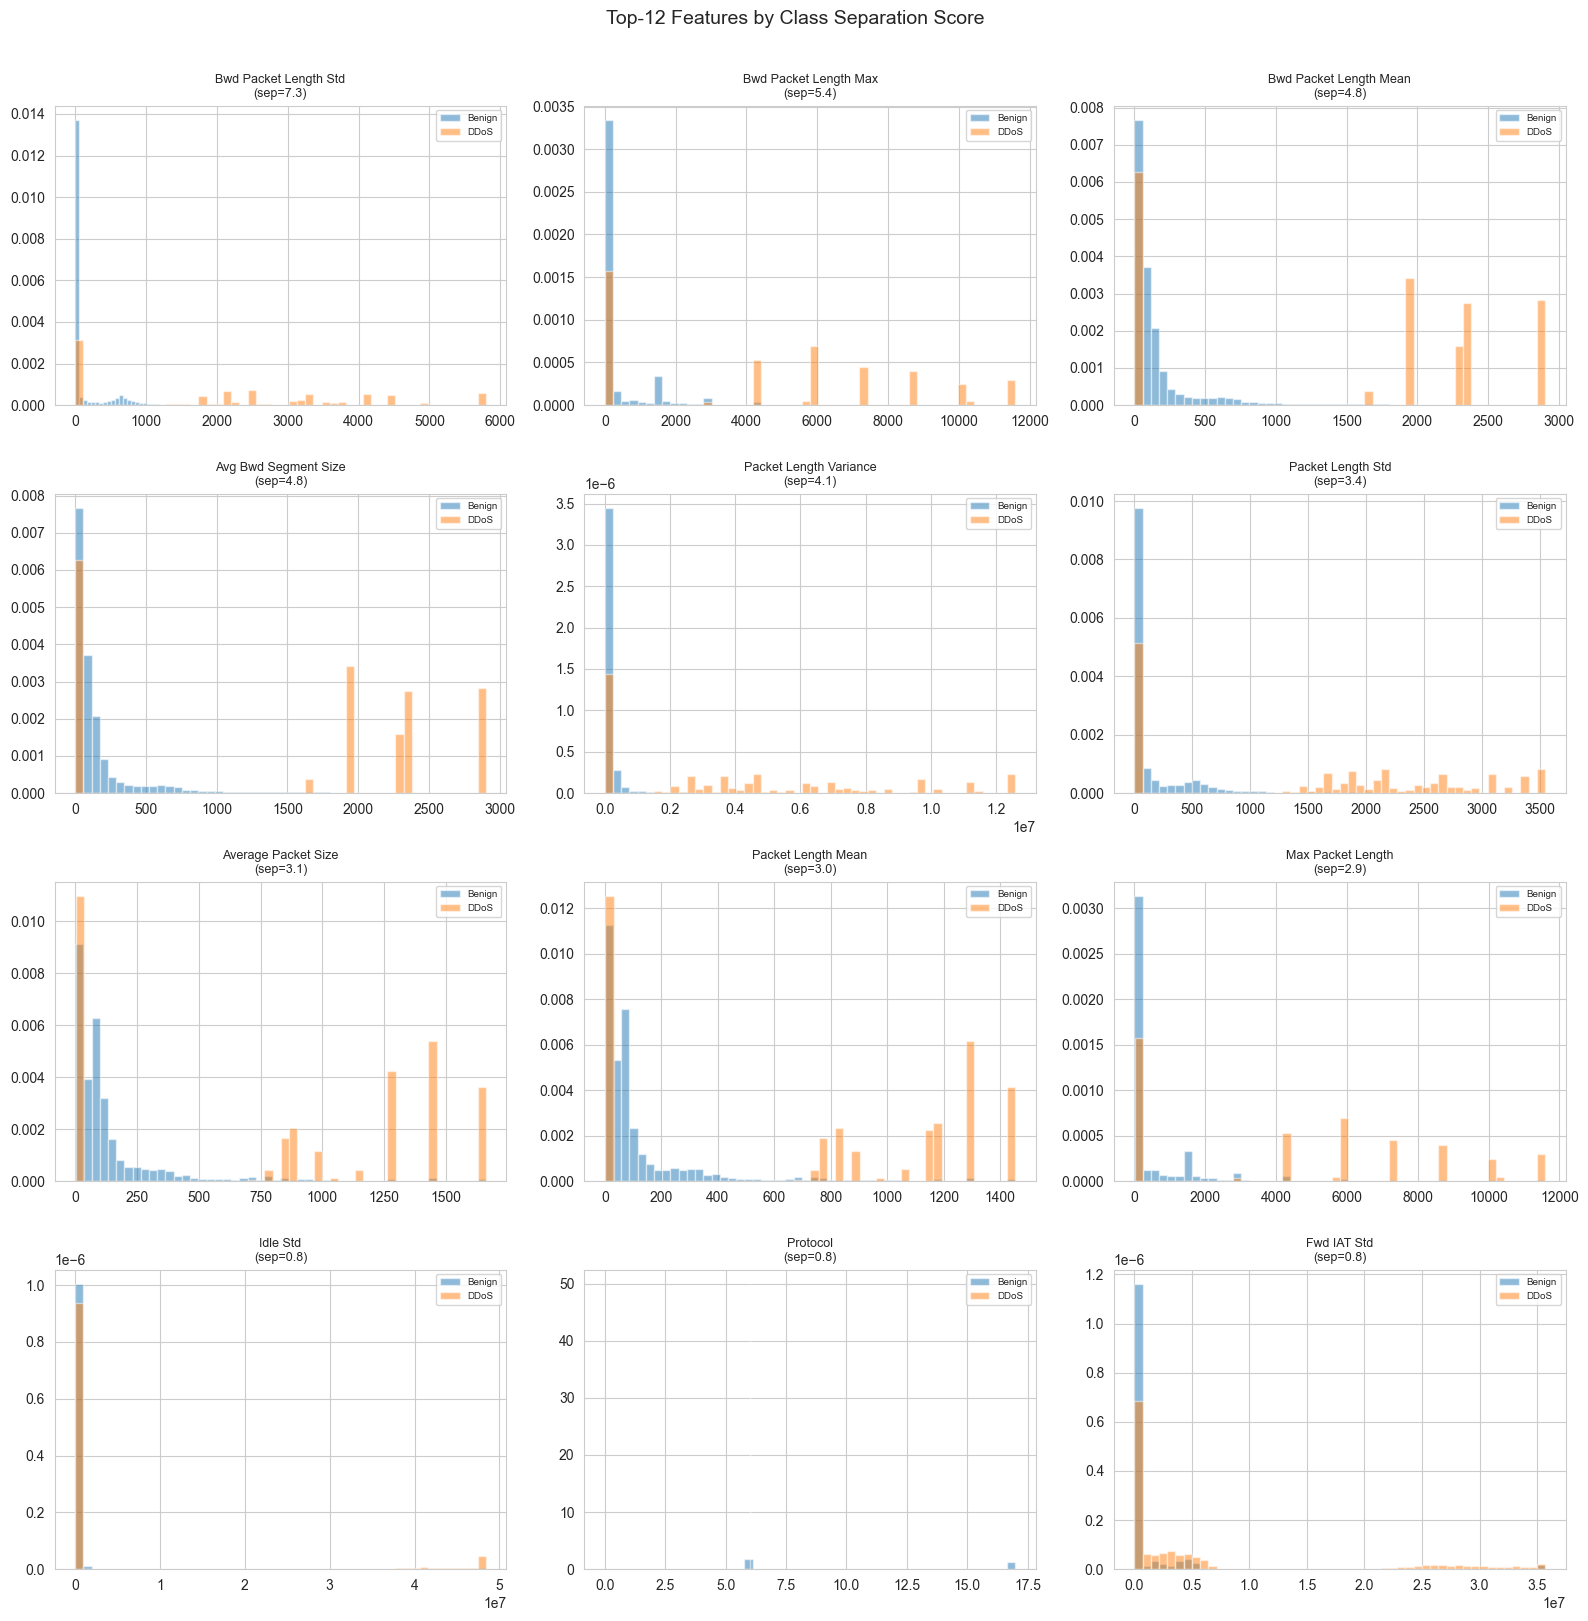

In [14]:
# Pick up to 12 features with highest variance ratio between classes
benign_mask = df_all['label'] == 0
attack_mask = df_all['label'] == 1

if attack_mask.sum() > 0 and benign_mask.sum() > 0:
    mean_b = df_all.loc[benign_mask, feature_cols].mean()
    mean_a = df_all.loc[attack_mask, feature_cols].mean()
    std_b  = df_all.loc[benign_mask, feature_cols].std().replace(0, 1e-10)
    # Separation score: |mean_attack - mean_benign| / std_benign
    sep_score = ((mean_a - mean_b).abs() / std_b).sort_values(ascending=False)

    top_feats = sep_score.head(12).index.tolist()
    n_plot = len(top_feats)
    ncols = 3
    nrows = (n_plot + ncols - 1) // ncols

    fig, axes = plt.subplots(nrows, ncols, figsize=(16, 4 * nrows))
    axes = axes.flatten()

    for i, feat in enumerate(top_feats):
        ax = axes[i]
        # Clip at 99th percentile for visualization
        clip_val = df_all[feat].quantile(0.99)
        data_b = df_all.loc[benign_mask, feat].clip(upper=clip_val)
        data_a = df_all.loc[attack_mask, feat].clip(upper=clip_val)
        ax.hist(data_b, bins=50, alpha=0.5, label='Benign', density=True)
        ax.hist(data_a, bins=50, alpha=0.5, label='DDoS', density=True)
        ax.set_title(f'{feat}\n(sep={sep_score[feat]:.1f})', fontsize=9)
        ax.legend(fontsize=7)

    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)

    plt.suptitle('Top-12 Features by Class Separation Score', fontsize=14, y=1.01)
    plt.tight_layout()
    plt.show()
else:
    print('Cannot plot — need both benign and attack samples.')

## 14. Correlation Analysis

Identify and remove highly correlated features (|r| > threshold). This prevents the IF feature-independence trap discovered in UC1 — redundant features give models no independent discriminative axis.

In [15]:
corr = df_all[feature_cols].corr().abs()

# Extract upper triangle (excluding diagonal)
upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

# Find pairs above threshold
high_corr_pairs = []
for col in upper.columns:
    for idx in upper.index:
        val = upper.loc[idx, col]
        if pd.notna(val) and val > CORR_THRESHOLD:
            high_corr_pairs.append((idx, col, val))

high_corr_pairs.sort(key=lambda x: x[2], reverse=True)

print(f'Highly correlated pairs (|r| > {CORR_THRESHOLD}): {len(high_corr_pairs)}')
print(f'{"Col A":40s}  {"Col B":40s}  |r|')
print('-' * 90)
for a, b, r in high_corr_pairs[:30]:
    print(f'{a:40s}  {b:40s}  {r:.4f}')
if len(high_corr_pairs) > 30:
    print(f'... and {len(high_corr_pairs) - 30} more pairs')

Highly correlated pairs (|r| > 0.95): 43
Col A                                     Col B                                     |r|
------------------------------------------------------------------------------------------
Fwd PSH Flags                             SYN Flag Count                            1.0000
Fwd Packet Length Mean                    Avg Fwd Segment Size                      1.0000
Bwd Packet Length Mean                    Avg Bwd Segment Size                      1.0000
Fwd Header Length                         Fwd Header Length.1                       1.0000
Total Fwd Packets                         Subflow Fwd Packets                       1.0000
Total Length of Fwd Packets               Subflow Fwd Bytes                         1.0000
Total Backward Packets                    Subflow Bwd Packets                       1.0000
Total Length of Bwd Packets               Subflow Bwd Bytes                         1.0000
Total Fwd Packets                         act_data_p

## 15. Drop Correlated Features

For each correlated pair, drop the column with lower mean absolute correlation to the target (keeps the more predictive one).

In [16]:
# Compute correlation with target for each feature
target_corr = df_all[feature_cols].corrwith(df_all['label']).abs()

# Greedy removal: for each pair, drop the one less correlated with target
to_drop = set()
for a, b, r in high_corr_pairs:
    if a in to_drop or b in to_drop:
        continue  # already scheduled for removal
    # Drop the feature with lower target correlation
    if target_corr.get(a, 0) >= target_corr.get(b, 0):
        to_drop.add(b)
    else:
        to_drop.add(a)

to_drop = sorted(to_drop)
print(f'Dropping {len(to_drop)} correlated features:')
for c in to_drop:
    print(f'  {c}')

df_all.drop(columns=to_drop, inplace=True)
feature_cols = [c for c in feature_cols if c not in to_drop]
print(f'\nRemaining features: {len(feature_cols)}')

Dropping 23 correlated features:
  Average Packet Size
  Avg Bwd Segment Size
  Avg Fwd Segment Size
  Bwd IAT Min
  Bwd Packet Length Max
  Bwd Packet Length Mean
  Flow Duration
  Flow IAT Max
  Fwd Header Length.1
  Fwd IAT Max
  Fwd Packet Length Std
  Fwd Packets/s
  Idle Mean
  Max Packet Length
  Packet Length Mean
  SYN Flag Count
  Subflow Bwd Bytes
  Subflow Bwd Packets
  Subflow Fwd Bytes
  Subflow Fwd Packets
  Total Fwd Packets
  Total Length of Bwd Packets
  act_data_pkt_fwd

Remaining features: 45


## 16. Final Feature Set

In [17]:
print(f'Final feature count: {len(feature_cols)}')
print()
for i, c in enumerate(feature_cols):
    tc = target_corr.get(c, 0)
    print(f'  {i+1:3d}. {c:45s}  |corr_target|={tc:.4f}')

# Save feature list for downstream notebooks
import json
feat_list_path = os.path.join(OUTPUT_DIR, 'flow_feature_cols.json')
with open(feat_list_path, 'w') as f:
    json.dump(feature_cols, f, indent=2)
print(f'\nFeature list saved to {feat_list_path}')

Final feature count: 45

    1. Source Port                                    |corr_target|=0.1191
    2. Destination Port                               |corr_target|=0.2170
    3. Protocol                                       |corr_target|=0.3236
    4. Total Backward Packets                         |corr_target|=0.0029
    5. Total Length of Fwd Packets                    |corr_target|=0.0510
    6. Fwd Packet Length Max                          |corr_target|=0.1154
    7. Fwd Packet Length Min                          |corr_target|=0.0972
    8. Fwd Packet Length Mean                         |corr_target|=0.1202
    9. Bwd Packet Length Min                          |corr_target|=0.2544
   10. Bwd Packet Length Std                          |corr_target|=0.6762
   11. Flow Bytes/s                                   |corr_target|=0.0239
   12. Flow Packets/s                                 |corr_target|=0.1085
   13. Flow IAT Mean                                  |corr_target|=0.0654


## 17. Correlation Heatmap (Reduced Feature Set)

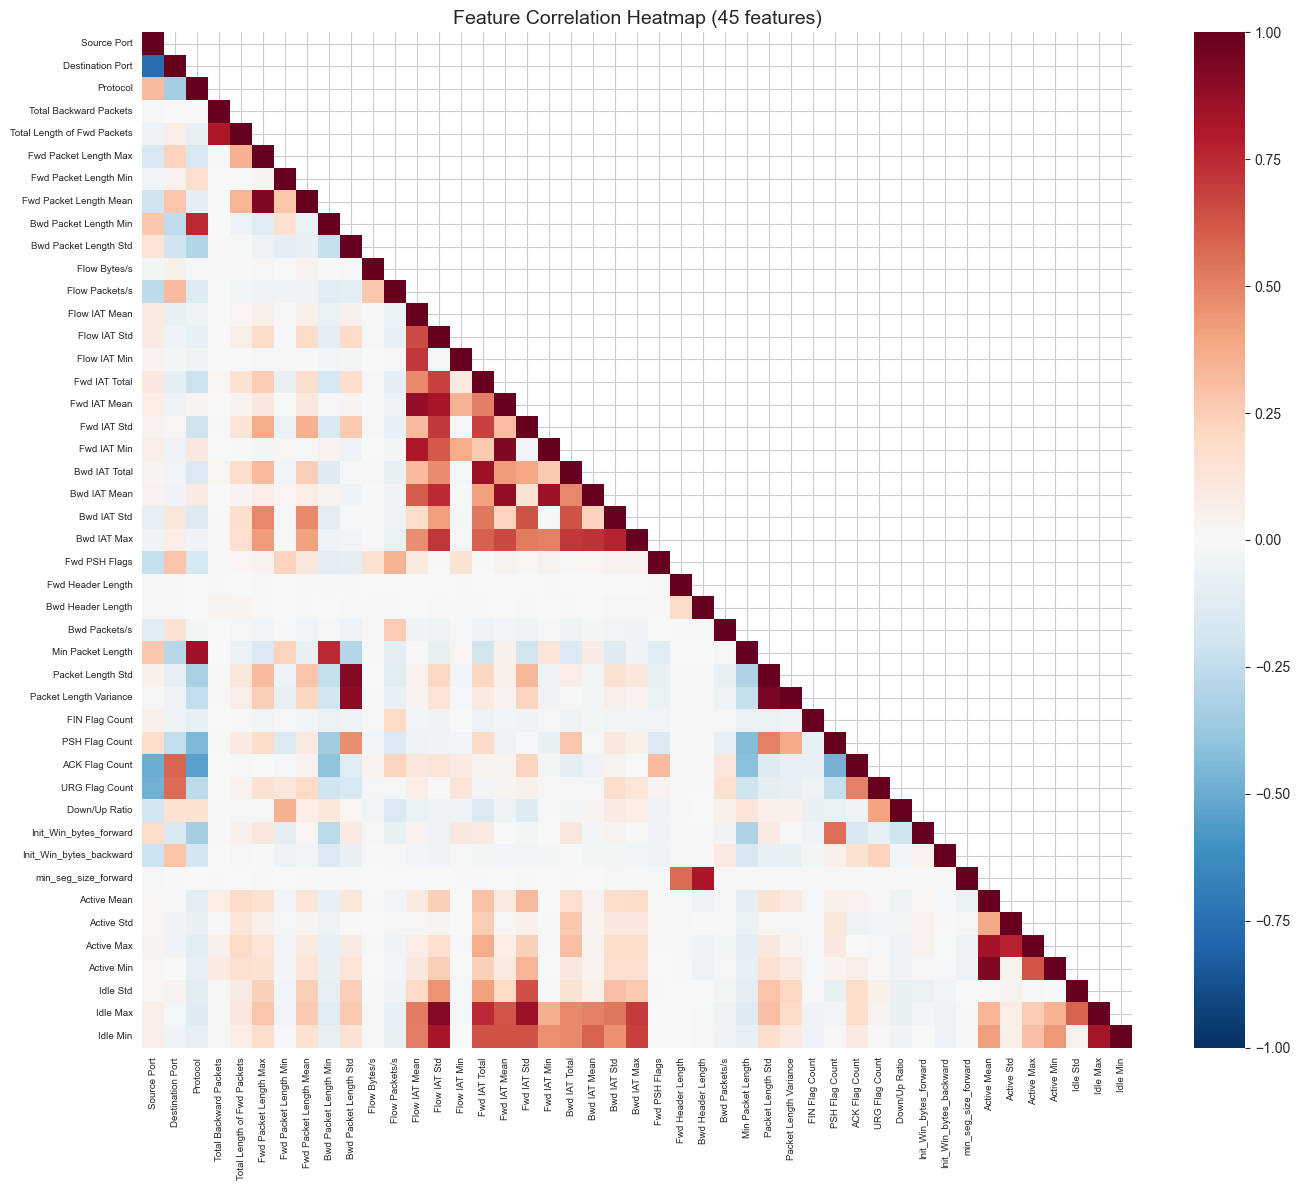

Max pairwise correlation in final set: 0.9468
All pairwise correlations below threshold.


In [18]:
corr_final = df_all[feature_cols].corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr_final, dtype=bool), k=1)
sns.heatmap(corr_final, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=False,
            xticklabels=True, yticklabels=True, ax=ax)
ax.set_title(f'Feature Correlation Heatmap ({len(feature_cols)} features)', fontsize=14)
plt.xticks(fontsize=7, rotation=90)
plt.yticks(fontsize=7)
plt.tight_layout()
plt.show()

# Sanity: max off-diagonal correlation
upper_final = corr_final.abs().where(
    np.triu(np.ones(corr_final.shape), k=1).astype(bool))
max_corr = upper_final.max().max()
print(f'Max pairwise correlation in final set: {max_corr:.4f}')
assert max_corr <= CORR_THRESHOLD, f'Correlation still exceeds threshold ({max_corr:.4f})'
print('All pairwise correlations below threshold.')

## 18. Temporal Train/Test Split

**Strategy:** Split within the Friday DDoS file by timestamp to maintain
temporal ordering (no future-leaking). Monday benign data is always
training-only.

| Partition | Source |
|-----------|--------|
| **Train** | All Monday (benign) + first portion of Friday DDoS file |
| **Test**  | Remaining portion of Friday DDoS file |

The split boundary is placed such that approximately 70% of the Friday DDoS
rows go to training and 30% to testing, at the nearest timestamp boundary
that doesn't split flows within the same second.

In [19]:
FRIDAY_TRAIN_RATIO = 0.7

# Monday → always train
monday_mask = df_all['_source'] == 'monday'
friday_mask = df_all['_source'] == 'friday_ddos'

df_monday = df_all[monday_mask].copy()
df_friday = df_all[friday_mask].copy()

print(f'Monday rows:  {len(df_monday):>10,}  (all train)')
print(f'Friday rows:  {len(df_friday):>10,}  (to be split)')

if 'Timestamp' in df_friday.columns and df_friday['Timestamp'].notna().all():
    # Sort by timestamp to ensure temporal ordering
    df_friday = df_friday.sort_values('Timestamp').reset_index(drop=True)

    # Find the split boundary timestamp
    split_idx = int(len(df_friday) * FRIDAY_TRAIN_RATIO)
    split_ts = df_friday.iloc[split_idx]['Timestamp']

    # Snap to second boundary (don't split mid-second)
    split_ts_floor = split_ts.floor('s')
    fri_train_mask = df_friday['Timestamp'] < split_ts_floor
    fri_test_mask  = df_friday['Timestamp'] >= split_ts_floor

    df_fri_train = df_friday[fri_train_mask].copy()
    df_fri_test  = df_friday[fri_test_mask].copy()

    print(f'\nFriday split boundary: {split_ts_floor}')
else:
    # Fallback: use row order
    split_idx = int(len(df_friday) * FRIDAY_TRAIN_RATIO)
    df_fri_train = df_friday.iloc[:split_idx].copy()
    df_fri_test  = df_friday.iloc[split_idx:].copy()
    print(f'\nFriday split boundary: row index {split_idx}')

# Combine Monday + Friday-train for full training set
df_train = pd.concat([df_monday, df_fri_train], ignore_index=True)
df_test  = df_fri_test.reset_index(drop=True)

print(f'\nTrain: {len(df_train):>10,} rows')
print(f'Test:  {len(df_test):>10,} rows')

Monday rows:     528,512  (all train)
Friday rows:     225,612  (to be split)

Friday split boundary: row index 157928

Train:    686,440 rows
Test:      67,684 rows


## 19. Split Verification

In [20]:
for name, df_split in [('Train', df_train), ('Test', df_test)]:
    print(f'\n── {name} ──')
    vc = df_split['label'].value_counts().sort_index()
    for lbl, cnt in vc.items():
        pct = 100 * cnt / len(df_split)
        tag = 'BENIGN' if lbl == 0 else 'DDoS'
        print(f'  {lbl} ({tag:8s})  {cnt:>10,}  ({pct:5.1f}%)')

    # Source breakdown
    src_vc = df_split['_source'].value_counts()
    print(f'  Sources: {dict(src_vc)}')

    # Timestamp range
    if 'Timestamp' in df_split.columns and df_split['Timestamp'].notna().any():
        ts = df_split['Timestamp']
        print(f'  Time range: {ts.min()} → {ts.max()}')


── Train ──
  0 (BENIGN  )     585,293  ( 85.3%)
  1 (DDoS    )     101,147  ( 14.7%)
  Sources: {'monday': np.int64(528512), 'friday_ddos': np.int64(157928)}
  Time range: 2017-07-03 01:00:01 → 2017-07-03 12:59:58

── Test ──
  0 (BENIGN  )      40,804  ( 60.3%)
  1 (DDoS    )      26,880  ( 39.7%)
  Sources: {'friday_ddos': np.int64(67684)}


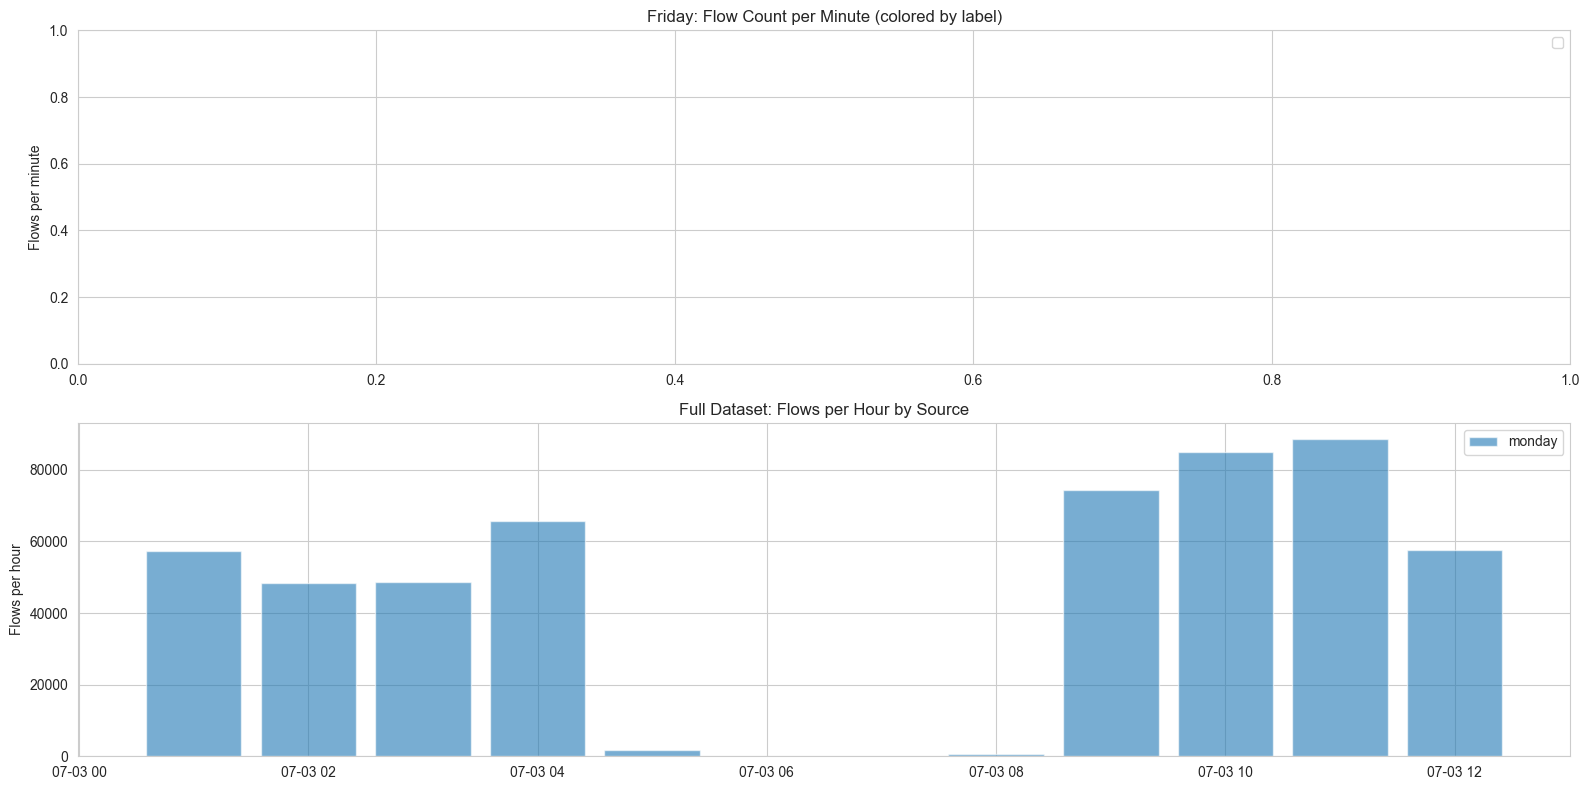

In [21]:
if 'Timestamp' in df_all.columns and df_all['Timestamp'].notna().any():
    fig, axes = plt.subplots(2, 1, figsize=(16, 8), sharex=False)

    # Plot 1: Friday timeline showing train/test boundary
    friday_all = df_all[df_all['_source'] == 'friday_ddos'].copy()
    if 'Timestamp' in friday_all.columns:
        friday_all = friday_all.sort_values('Timestamp')
        friday_all['minute'] = friday_all['Timestamp'].dt.floor('min')

        fri_by_min = friday_all.groupby(['minute', 'label']).size().unstack(fill_value=0)
        ax = axes[0]
        if 0 in fri_by_min.columns:
            ax.bar(fri_by_min.index, fri_by_min[0], width=pd.Timedelta('50s'),
                   label='Benign', alpha=0.7, color='steelblue')
        if 1 in fri_by_min.columns:
            bottom = fri_by_min.get(0, 0)
            ax.bar(fri_by_min.index, fri_by_min[1], width=pd.Timedelta('50s'),
                   bottom=bottom, label='DDoS', alpha=0.7, color='crimson')
        if 'split_ts_floor' in dir():
            ax.axvline(split_ts_floor, color='black', linestyle='--',
                       linewidth=2, label='Train/Test boundary')
        ax.set_title('Friday: Flow Count per Minute (colored by label)')
        ax.set_ylabel('Flows per minute')
        ax.legend()

    # Plot 2: Combined timeline
    ax2 = axes[1]
    for src, color in [('monday', 'steelblue'), ('friday_ddos', 'crimson')]:
        subset = df_all[df_all['_source'] == src]
        if 'Timestamp' in subset.columns and subset['Timestamp'].notna().any():
            subset_sorted = subset.sort_values('Timestamp')
            by_hr = subset_sorted.groupby(
                subset_sorted['Timestamp'].dt.floor('h')).size()
            ax2.bar(by_hr.index, by_hr.values,
                    width=pd.Timedelta('50min'), alpha=0.6, label=src)
    ax2.set_title('Full Dataset: Flows per Hour by Source')
    ax2.set_ylabel('Flows per hour')
    ax2.legend()

    plt.tight_layout()
    plt.show()
else:
    print('No Timestamp column — skipping temporal visualization.')

## 20. Class Balance Analysis

Check imbalance ratio to inform XGBoost's `scale_pos_weight` parameter in the downstream training notebook.

In [22]:
n_benign_train = (df_train['label'] == 0).sum()
n_attack_train = (df_train['label'] == 1).sum()
imbalance_ratio = n_benign_train / max(n_attack_train, 1)

print(f'Training set:')
print(f'  Benign: {n_benign_train:>10,}')
print(f'  Attack: {n_attack_train:>10,}')
print(f'  Imbalance ratio (benign/attack): {imbalance_ratio:.2f}')
print(f'  Suggested scale_pos_weight: {imbalance_ratio:.2f}')

n_benign_test = (df_test['label'] == 0).sum()
n_attack_test = (df_test['label'] == 1).sum()
print(f'\nTest set:')
print(f'  Benign: {n_benign_test:>10,}')
print(f'  Attack: {n_attack_test:>10,}')

Training set:
  Benign:    585,293
  Attack:    101,147
  Imbalance ratio (benign/attack): 5.79
  Suggested scale_pos_weight: 5.79

Test set:
  Benign:     40,804
  Attack:     26,880


## 21. Descriptive Statistics (Final Feature Set)

In [23]:
desc = df_all[feature_cols].describe().T
desc['nunique'] = df_all[feature_cols].nunique()
desc['skew']    = df_all[feature_cols].skew()

# Highlight potential issues
desc['needs_attention'] = ''
for c in feature_cols:
    issues = []
    if desc.loc[c, 'std'] == 0:
        issues.append('ZERO_VAR')
    if abs(desc.loc[c, 'skew']) > 10:
        issues.append('HIGH_SKEW')
    if desc.loc[c, 'nunique'] < 5:
        issues.append('LOW_UNIQUE')
    desc.loc[c, 'needs_attention'] = ', '.join(issues)

display(desc[['mean', 'std', 'min', '25%', '50%', '75%', 'max',
              'nunique', 'skew', 'needs_attention']])

,mean,std,min,25%,50%,75%,max,nunique,skew,needs_attention
Source Port,3.977185e+04,2.398757e+04,0.000000e+00,16719.000000,51653.000000,5.936200e+04,6.553500e+04,62348,-0.754872,
Destination Port,1.012894e+04,2.094052e+04,0.000000e+00,53.000000,80.000000,4.430000e+02,6.553500e+04,38349,1.705874,
Protocol,9.729816e+00,5.212061e+00,0.000000e+00,6.000000,6.000000,1.700000e+01,1.700000e+01,3,0.675892,LOW_UNIQUE
Total Backward Packets,9.461295e+00,9.836325e+02,0.000000e+00,1.000000,2.000000,5.000000e+00,2.919220e+05,898,269.718852,HIGH_SKEW
Total Length of Fwd Packets,6.546046e+02,5.518690e+03,0.000000e+00,24.000000,56.000000,1.280000e+02,1.323378e+06,10138,151.481554,HIGH_SKEW
Fwd Packet Length Max,2.952434e+02,1.098647e+03,0.000000e+00,6.000000,35.000000,5.600000e+01,2.336000e+04,3748,6.970403,
Fwd Packet Length Min,2.249068e+01,9.442189e+01,0.000000e+00,0.000000,6.000000,3.600000e+01,2.293000e+03,237,13.520882,HIGH_SKEW
Fwd Packet Length Mean,8.489178e+01,2.915079e+02,0.000000e+00,6.000000,32.000000,4.900000e+01,4.638923e+03,46992,6.101527,
Bwd Packet Length Min,4.007182e+01,7.016794e+01,0.000000e+00,0.000000,0.000000,7.400000e+01,2.146000e+03,457,5.103738,
Bwd Packet Length Std,4.605194e+02,1.098067e+03,0.000000e+00,0.000000,0.000000,2.849728e+02,8.194660e+03,72986,2.982738,


## 22. Export Clean CSVs

Export training and test sets with only the selected features + label + timestamp.

In [24]:
export_cols = feature_cols + ['label', 'label_orig']
if 'Timestamp' in df_train.columns:
    export_cols = ['Timestamp'] + export_cols

train_path = os.path.join(OUTPUT_DIR, 'train.csv')
test_path  = os.path.join(OUTPUT_DIR, 'test.csv')

df_train[export_cols].to_csv(train_path, index=False)
df_test[export_cols].to_csv(test_path, index=False)

print(f'Exported:')
print(f'  Train: {train_path}  ({len(df_train):,} rows x {len(export_cols)} cols)')
print(f'  Test:  {test_path}  ({len(df_test):,} rows x {len(export_cols)} cols)')

# File sizes
for p in [train_path, test_path]:
    size_mb = os.path.getsize(p) / (1024 * 1024)
    print(f'  {os.path.basename(p):30s}  {size_mb:.1f} MB')

Exported:
  Train: ./data/train.csv  (686,440 rows x 48 cols)
  Test:  ./data/test.csv  (67,684 rows x 48 cols)
  train.csv                       195.8 MB
  test.csv                        16.7 MB


## 23. Per-Class Feature Statistics

Compute per-class quantiles (p5, p25, p50, p75, p95) over the training set for each of the 45 features. The simulation service loads this file from MinIO to generate realistic synthetic CICFlowMeter flows — benign flows are sampled from the benign distribution, DDoS flows from the attack distribution.

In [25]:
PERCENTILES = [5, 25, 50, 75, 95]

class_stats: dict = {}
for class_val, class_name in [(0, 'benign'), (1, 'attack')]:
    mask = df_train['label'] == class_val
    class_df = df_train.loc[mask, feature_cols]
    qs = class_df.quantile([p / 100 for p in PERCENTILES])
    class_stats[class_name] = {
        feat: {f'p{p}': round(float(qs.loc[p / 100, feat]), 6) for p in PERCENTILES}
        for feat in feature_cols
    }
    print(f'{class_name}: {mask.sum():,} rows')

stats_path = os.path.join(OUTPUT_DIR, 'class_stats.json')
with open(stats_path, 'w') as f:
    json.dump(class_stats, f, indent=2)

print(f'\nClass stats saved: {stats_path}')
print(f'\nSample — Fwd Packet Length Max:')
for cls in ['benign', 'attack']:
    print(f'  {cls}: {class_stats[cls]["Fwd Packet Length Max"]}')

benign: 585,293 rows
attack: 101,147 rows

Class stats saved: ./data/class_stats.json

Sample — Fwd Packet Length Max:
  benign: {'p5': 0.0, 'p25': 6.0, 'p50': 40.0, 'p75': 190.0, 'p95': 1333.0}
  attack: {'p5': 6.0, 'p25': 6.0, 'p50': 20.0, 'p75': 20.0, 'p95': 20.0}


## 24. Summary

In [26]:
print('=' * 70)
print('UC2 DATA PREPARATION SUMMARY')
print('=' * 70)
print(f'Dataset:          CICIDS2017 (Monday + Friday DDoS)')
print(f'Original columns: ~80 CICFlowMeter features')
print(f'Final features:   {len(feature_cols)}')
print(f'')
print(f'Training set:     {len(df_train):>10,} rows')
print(f'  Benign:         {(df_train["label"]==0).sum():>10,}')
print(f'  DDoS:           {(df_train["label"]==1).sum():>10,}')
print(f'Test set:         {len(df_test):>10,} rows')
print(f'  Benign:         {(df_test["label"]==0).sum():>10,}')
print(f'  DDoS:           {(df_test["label"]==1).sum():>10,}')
print(f'')
print(f'Imbalance ratio:  {imbalance_ratio:.2f}')
print(f'Split method:     Temporal (within Friday)')
print(f'')
print(f'Exported files:')
print(f'  {train_path}')
print(f'  {test_path}')
print(f'  {feat_list_path}')
print('=' * 70)

print(f'   {feat_list_path} for feature parity.')

UC2 DATA PREPARATION SUMMARY
Dataset:          CICIDS2017 (Monday + Friday DDoS)
Original columns: ~80 CICFlowMeter features
Final features:   45

Training set:        686,440 rows
  Benign:            585,293
  DDoS:              101,147
Test set:             67,684 rows
  Benign:             40,804
  DDoS:               26,880

Imbalance ratio:  5.79
Split method:     Temporal (within Friday)

Exported files:
  ./data/train.csv
  ./data/test.csv
  ./data/flow_feature_cols.json
   ./data/flow_feature_cols.json for feature parity.
